# Import Required Libraries
Import the necessary libraries, including TensorFlow, Keras, and other dependencies.

In [1]:
# Importieren der benötigten Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import pymongo
import os
from tensorflow.keras.utils import Sequence, to_categorical
import gc
from tqdm import tqdm
from tensorflow.keras.applications import MobileNetV2
import tensorflow as tf
import random

# Funktion zur Datenbankverbindung und Datenladung
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    # Daten laden
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    # In DataFrames konvertieren
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    # Merge der DataFrames
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                        left_on='fingerprintId', 
                        right_on='_id', 
                        suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Daten laden
merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Beispielbenutzer auswählen (z.B. 'benutzername_1')
example_user_id = 'benutzername_1'

2024-11-23 14:40:48.253671: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-23 14:40:48.430583: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-23 14:40:48.868292: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


KeyboardInterrupt: 

In [ ]:
# Funktion zur Verarbeitung der Bilder in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):  # Ändere die Zielgröße auf (224, 224)
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Konvertiere Bild zu RGB
        image = image.resize(target_size)
        image_array = np.array(image)  # Keine Normalisierung
        return image_array
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

def extract_images_from_df(df):
    images = []
    labels = []
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Lade Bilder"):
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

In [ ]:
# Funktion zur Erstellung und Optimierung der Modelle
def create_optimized_models(base_model):
    models = {}

    # Modell 1
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model_1 = Model(inputs=base_model.input, outputs=predictions)
    models['MobileNet_Model_1'] = model_1

    # Modell 2
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model_2 = Model(inputs=base_model.input, outputs=predictions)
    models['MobileNet_Model_2'] = model_2

    # Modell 3
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model_3 = Model(inputs=base_model.input, outputs=predictions)
    models['MobileNet_Model_3'] = model_3

    # Modell 4
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model_4 = Model(inputs=base_model.input, outputs=predictions)
    models['MobileNet_Model_4'] = model_4

    # Modell 5
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model_5 = Model(inputs=base_model.input, outputs=predictions)
    models['MobileNet_Model_5'] = model_5

    return models

# Basismodell laden
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Optimierte Modelle erstellen
models = create_optimized_models(base_model)

# Modelle kompilieren
def compile_models(models):
    for model_name, model in models.items():
        model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

compile_models(models)

In [ ]:
# Early Stopping Callback definieren
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modelle trainieren
def train_models(models, X_train, y_train, X_val, y_val, epochs=20):  # Standardmäßig auf 20 Epochen gesetzt
    histories = {}
    for model_name, model in models.items():
        print(f"Training {model_name}...")
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,  # Anzahl der Epochen hier einstellen
            batch_size=32,
            callbacks=[early_stopping],
            verbose=1
        )
        histories[model_name] = history
    return histories

# Modelle evaluieren
def evaluate_models(models, X_test, y_test):
    results = {}
    for model_name, model in models.items():
        print(f"Evaluierung von {model_name}...")
        y_pred_prob = model.predict(X_test)
        y_pred = (y_pred_prob > 0.5).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        cr = classification_report(y_test, y_pred)
        results[model_name] = {'confusion_matrix': cm, 'classification_report': cr}
        print(f"Konfusionsmatrix für {model_name}:\n{cm}")
        print(f"Klassifikationsbericht für {model_name}:\n{cr}")
    return results

# Funktion zur Berechnung und Anzeige der Score-Bewertung
def calculate_scores(evaluation_results):
    scores = {}
    for model_name, result in evaluation_results.items():
        cm = result['confusion_matrix']
        tn, fp, fn, tp = cm.ravel()
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        scores[model_name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1_score
        }
    return scores

In [ ]:
# Funktion zur automatischen Optimierung der Modelle
def optimize_models(models, user_dfs, example_user_id, num_iterations=1, num_users=20, num_samples_per_user=10000):
    best_models = {}
    best_scores = {}
    all_histories = {}
    all_evaluation_results = {}

    for iteration in range(num_iterations):
        print(f"Iteration {iteration + 1}/{num_iterations}")
        
        # Daten aufteilen
        user_df = user_dfs[example_user_id].sample(n=num_samples_per_user * num_iterations, random_state=42)
        negative_df = pd.concat([user_dfs[user_id] for user_id in user_dfs.keys() if user_id != example_user_id])
        negative_df = negative_df.sample(n=num_samples_per_user * num_iterations, random_state=42)
        
        train_df, test_df = train_test_split(pd.concat([user_df, negative_df]), test_size=0.1, random_state=42)
        train_df, val_df = train_test_split(train_df, test_size=0.2222, random_state=42)  # 0.2222 * 0.9 ≈ 0.2
        
        # Bilddaten verarbeiten
        X_train, y_train = extract_images_from_df(train_df)
        X_val, y_val = extract_images_from_df(val_df)
        X_test, y_test = extract_images_from_df(test_df)
        
        # Speicher freigeben
        gc.collect()
        
        # Modelle trainieren
        histories = train_models(models, X_train, y_train, X_val, y_val)
        
        # Modelle evaluieren
        evaluation_results = evaluate_models(models, X_test, y_test)
        scores = calculate_scores(evaluation_results)
        
        # Beste Modelle und Scores speichern
        for model_name, score in scores.items():
            if model_name not in best_scores or score['F1 Score'] > best_scores[model_name]['F1 Score']:
                best_scores[model_name] = score
                best_models[model_name] = models[model_name]
                all_histories[model_name] = histories[model_name]
                all_evaluation_results[model_name] = evaluation_results[model_name]
    
    # Alle Modelle speichern
    save_models(models)
    
    return best_models, best_scores, all_histories, all_evaluation_results

# Ordner löschen
delete_directory()

# Ordner erstellen
create_directory()

# Optimierung der Modelle durchführen
best_models, best_scores, all_histories, all_evaluation_results = optimize_models(models, user_dfs, example_user_id)

Ordner models/version2 wurde gelöscht.
Ordner models/version2 wurde erstellt.
Iteration 1/1


Lade Bilder: 100%|██████████| 2000/2000 [00:00<00:00, 2265.06it/s]


Training MobileNet_Model_1...
Epoch 1/5
438/438 [==============================] - 31s 48ms/step - loss: 0.2637 - accuracy: 0.9090 - val_loss: 0.9507 - val_accuracy: 0.6380
Epoch 2/5
438/438 [==============================] - 19s 43ms/step - loss: 0.2358 - accuracy: 0.9209 - val_loss: 12.8574 - val_accuracy: 0.5123
Epoch 3/5
438/438 [==============================] - 19s 44ms/step - loss: 0.2366 - accuracy: 0.9211 - val_loss: 11.2979 - val_accuracy: 0.5095
Epoch 4/5
438/438 [==============================] - 19s 43ms/step - loss: 0.2457 - accuracy: 0.9179 - val_loss: 38.5843 - val_accuracy: 0.5095
Epoch 5/5
438/438 [==============================] - 19s 43ms/step - loss: 0.2310 - accuracy: 0.9229 - val_loss: 53.0215 - val_accuracy: 0.5095
Training MobileNet_Model_2...
Epoch 1/5
438/438 [==============================] - 29s 45ms/step - loss: 0.2491 - accuracy: 0.9167 - val_loss: 57.1407 - val_accuracy: 0.5095
Epoch 2/5
438/438 [==============================] - 19s 44ms/step - loss: 0.

/usr/local/lib/python3.8/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


MobileNet_Model_2 gespeichert.
MobileNet_Model_3 gespeichert.
MobileNet_Model_4 gespeichert.
MobileNet_Model_5 gespeichert.


Ergebnisse für MobileNet_Model_1:


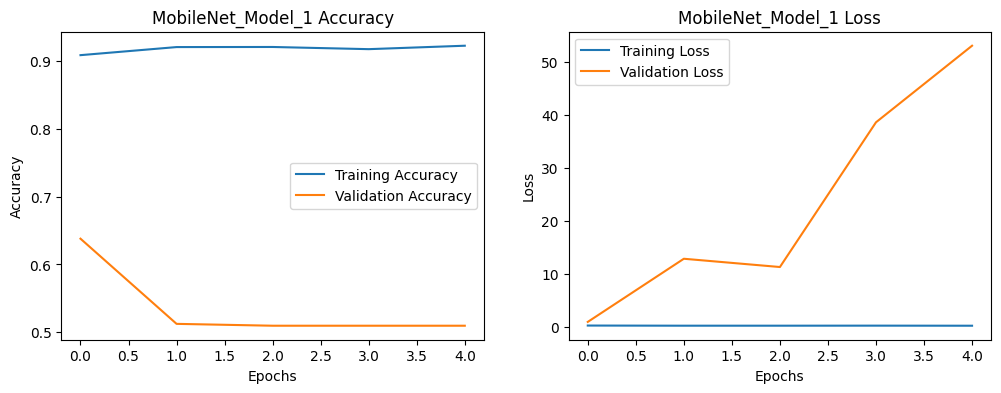

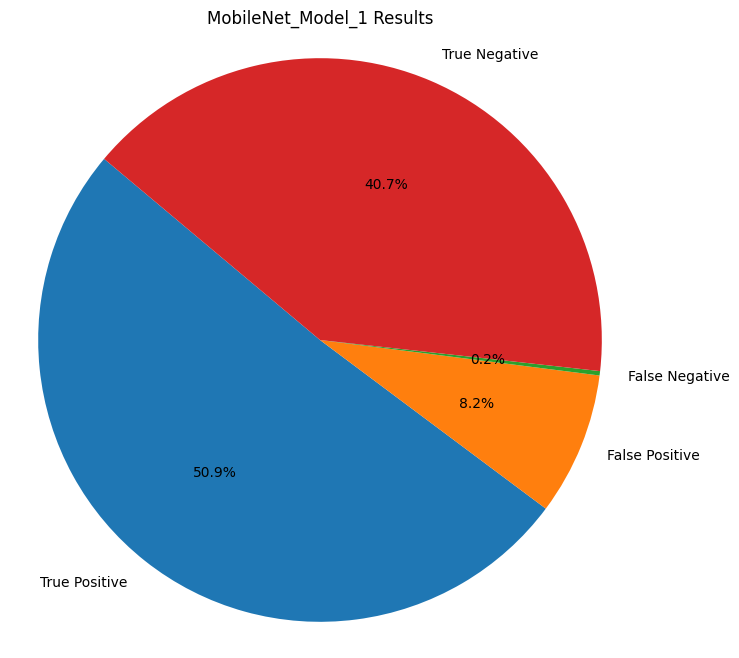

Statistiken für MobileNet_Model_1:
              precision    recall  f1-score   support

           0       0.99      0.83      0.91       977
           1       0.86      1.00      0.92      1023

    accuracy                           0.92      2000
   macro avg       0.93      0.91      0.91      2000
weighted avg       0.93      0.92      0.91      2000

True Positive: 1018, False Positive: 164, False Negative: 5, True Negative: 813


Accuracy: 0.9155
Precision: 0.8613
Recall: 0.9951
F1 Score: 0.9234


Ergebnisse für MobileNet_Model_2:


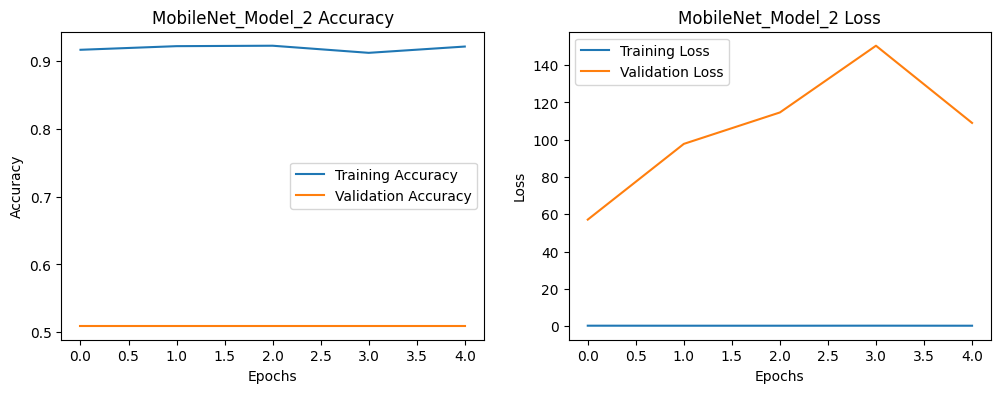

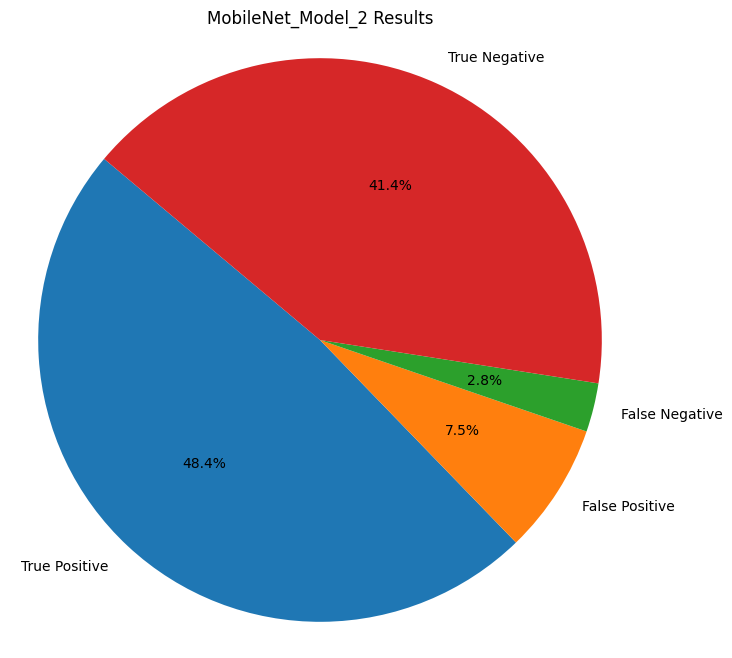

Statistiken für MobileNet_Model_2:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       977
           1       0.87      0.95      0.90      1023

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

True Positive: 967, False Positive: 150, False Negative: 56, True Negative: 827


Accuracy: 0.8970
Precision: 0.8657
Recall: 0.9453
F1 Score: 0.9037


Ergebnisse für MobileNet_Model_3:


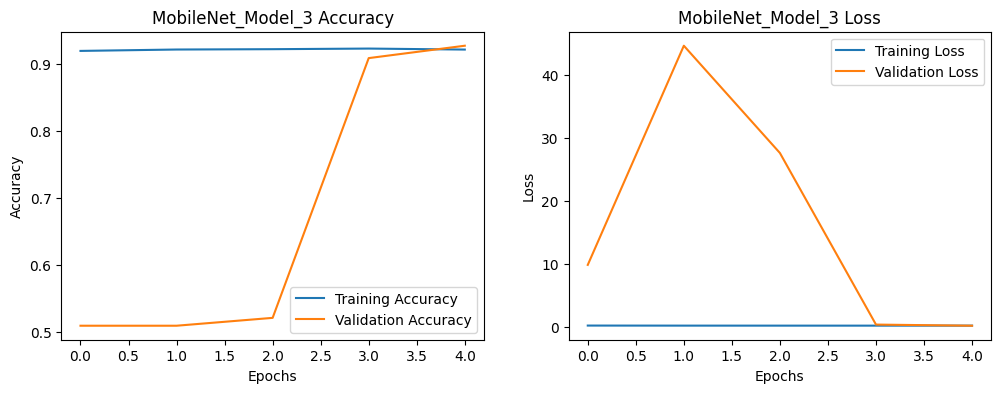

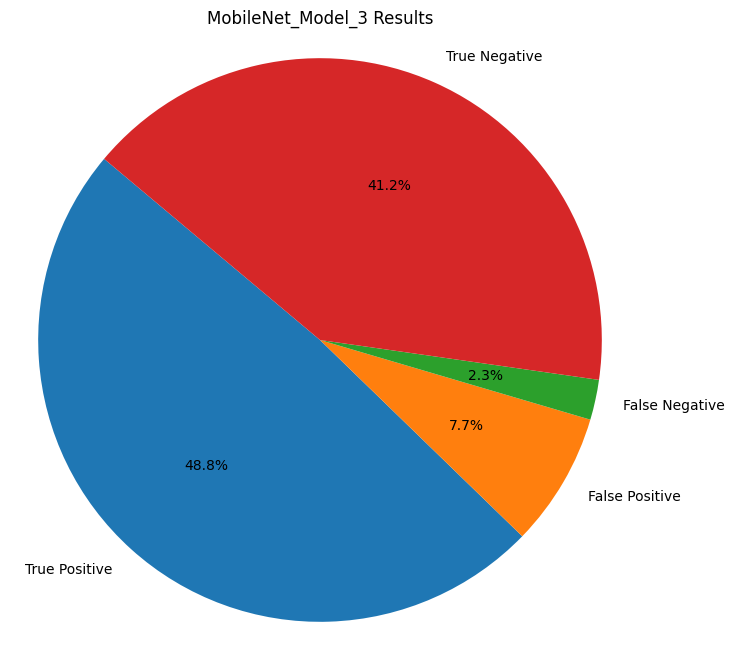

Statistiken für MobileNet_Model_3:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       977
           1       0.86      0.96      0.91      1023

    accuracy                           0.90      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

True Positive: 977, False Positive: 154, False Negative: 46, True Negative: 823


Accuracy: 0.9000
Precision: 0.8638
Recall: 0.9550
F1 Score: 0.9071


Ergebnisse für MobileNet_Model_4:


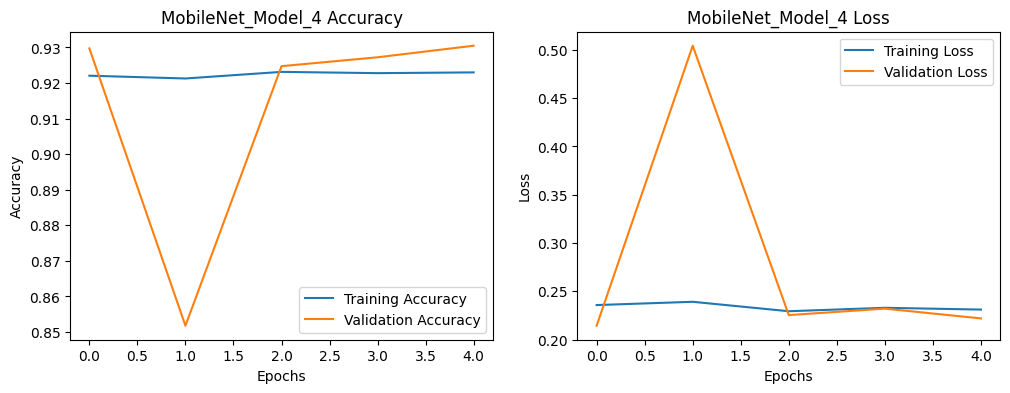

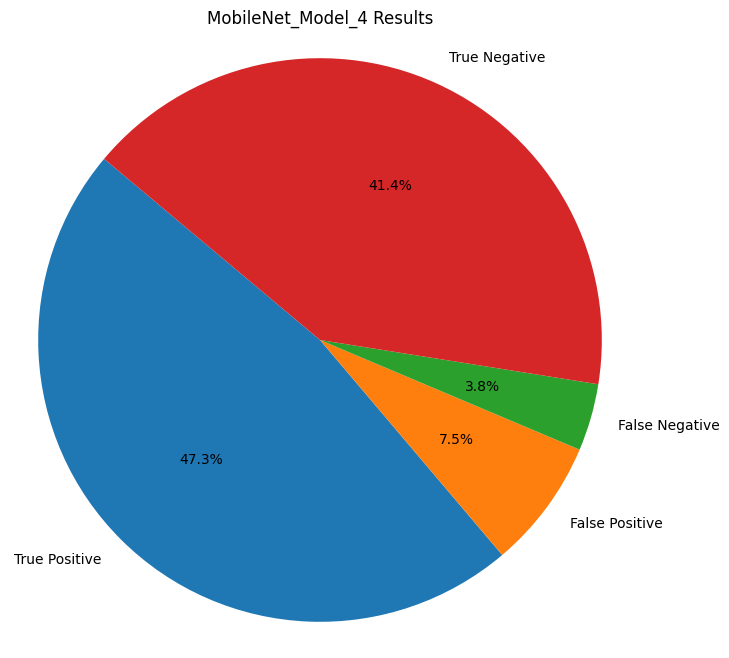

Statistiken für MobileNet_Model_4:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       977
           1       0.86      0.92      0.89      1023

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

True Positive: 946, False Positive: 149, False Negative: 77, True Negative: 828


Accuracy: 0.8870
Precision: 0.8639
Recall: 0.9247
F1 Score: 0.8933


Ergebnisse für MobileNet_Model_5:


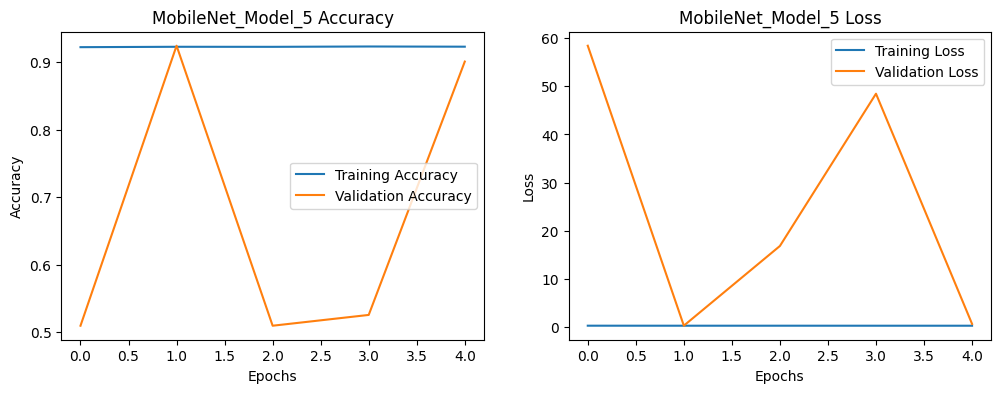

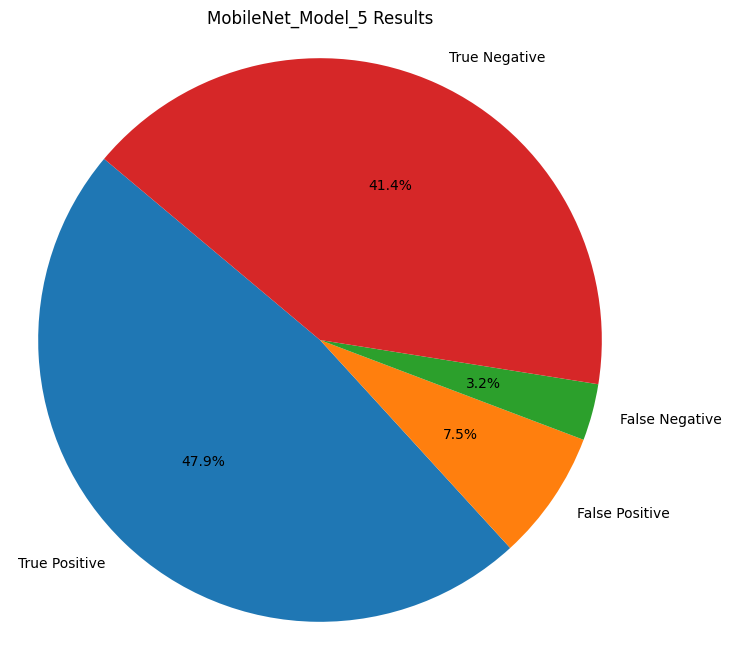

Statistiken für MobileNet_Model_5:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       977
           1       0.87      0.94      0.90      1023

    accuracy                           0.89      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.90      0.89      0.89      2000

True Positive: 958, False Positive: 149, False Negative: 65, True Negative: 828


Accuracy: 0.8930
Precision: 0.8654
Recall: 0.9365
F1 Score: 0.8995




In [ ]:
# Trainingsgeschichte plotten
def plot_histories(histories):
    for model_name, history in histories.items():
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title(f'{model_name} Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'{model_name} Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

def plot_results_pie_charts(results):
    for model_name, result in results.items():
        cm = result['confusion_matrix']
        tn, fp, fn, tp = cm.ravel()
        sizes = [tp, fp, fn, tn]
        labels = ['True Positive', 'False Positive', 'False Negative', 'True Negative']
        plt.figure(figsize=(8, 8))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
        plt.title(f'{model_name} Results')
        plt.axis('equal')
        plt.show()

def display_statistics(evaluation_results):
    for model_name, result in evaluation_results.items():
        print(f"Statistiken für {model_name}:")
        print(result['classification_report'])
        cm = result['confusion_matrix']
        tn, fp, fn, tp = cm.ravel()
        print(f"True Positive: {tp}, False Positive: {fp}, False Negative: {fn}, True Negative: {tn}")
        print("\n")

# Ergebnisse der besten Modelle anzeigen
for model_name, model in best_models.items():
    print(f"Ergebnisse für {model_name}:")
    plot_histories({model_name: all_histories[model_name]})
    plot_results_pie_charts({model_name: all_evaluation_results[model_name]})
    display_statistics({model_name: all_evaluation_results[model_name]})
    for metric, value in best_scores[model_name].items():
        print(f"{metric}: {value:.4f}")
    print("\n")

In [ ]:
import os
import shutil
from tensorflow.keras.models import load_model

# Funktion zum Löschen des Ordners
def delete_directory(directory='models/version2'):
    if os.path.exists(directory):
        shutil.rmtree(directory)
        print(f"Ordner {directory} wurde gelöscht.")
    else:
        print(f"Ordner {directory} existiert nicht.")

# Funktion zum Erstellen des Ordners
def create_directory(directory='models/version2'):
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Ordner {directory} wurde erstellt.")
    else:
        print(f"Ordner {directory} existiert bereits.")

# Modelle speichern
def save_models(models, directory='models/version2'):
    create_directory(directory)  # Ordner erstellen
    for model_name, model in models.items():
        model.save(os.path.join(directory, f'{model_name}.h5'))
        print(f"{model_name} gespeichert.")

# Modelle laden
def load_models(directory='models/version2'):
    loaded_models = {}
    if os.path.exists(directory):
        for model_file in os.listdir(directory):
            if model_file.endswith('.h5'):
                model_name = os.path.splitext(model_file)[0]
                model_path = os.path.join(directory, model_file)
                loaded_models[model_name] = load_model(model_path)
                print(f"{model_name} geladen.")
    else:
        print(f"Ordner {directory} existiert nicht.")
    return loaded_models





In [ ]:
# Modelle speichern (Beispiel: Hier sollten Ihre Modelle gespeichert werden)
save_models(models)

# Modelle aus dem Ordner laden
loaded_models = load_models()

Ordner models/version2 existiert bereits.
MobileNet_Model_1 gespeichert.
MobileNet_Model_2 gespeichert.
MobileNet_Model_3 gespeichert.
MobileNet_Model_4 gespeichert.
MobileNet_Model_5 gespeichert.
MobileNet_Model_5 geladen.
MobileNet_Model_4 geladen.
MobileNet_Model_3 geladen.
MobileNet_Model_2 geladen.
MobileNet_Model_1 geladen.


MobileNet_Model_5 geladen.
MobileNet_Model_4 geladen.
MobileNet_Model_3 geladen.
MobileNet_Model_2 geladen.
MobileNet_Model_1 geladen.
Analyse von MobileNet_Model_5 gegen zufällige Samples:
188/188 [==============================] - 3s 13ms/step
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      5000
           1       0.00      0.00      0.00      1000

    accuracy                           0.83      6000
   macro avg       0.42      0.50      0.45      6000
weighted avg       0.69      0.83      0.76      6000



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


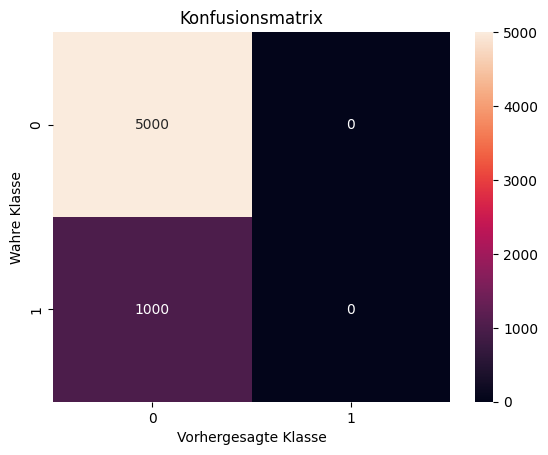

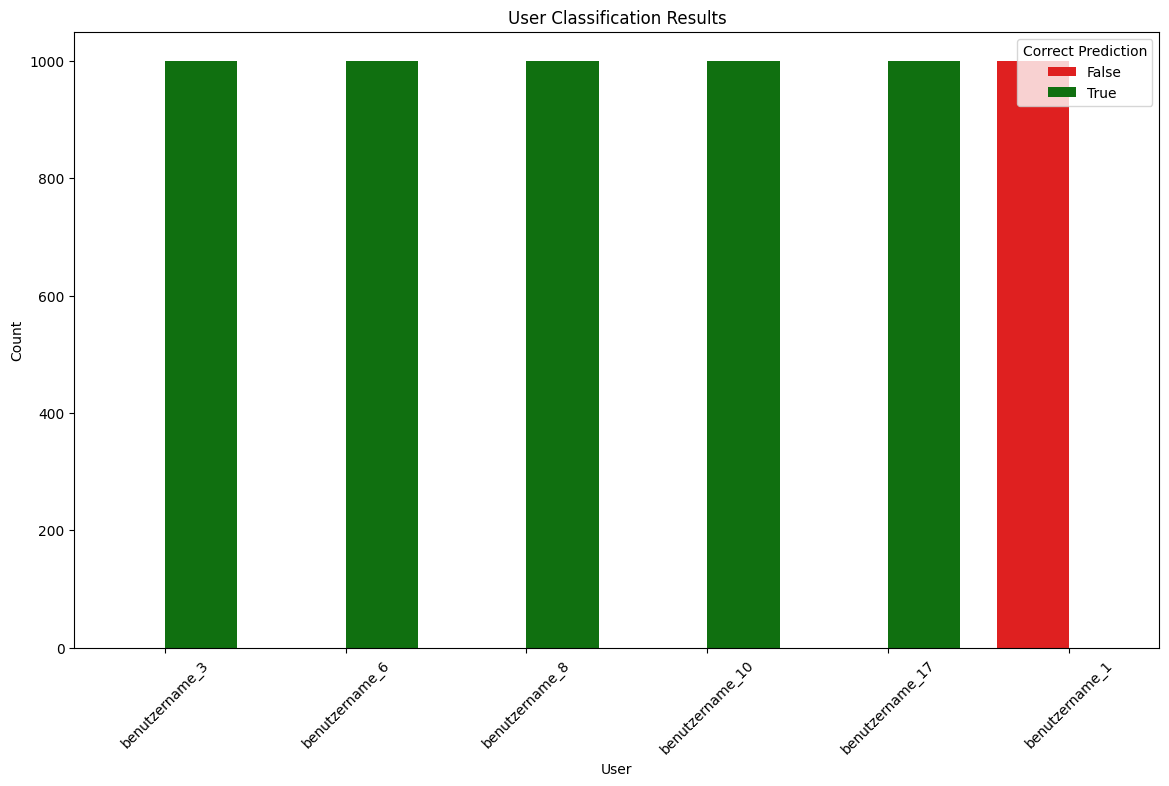

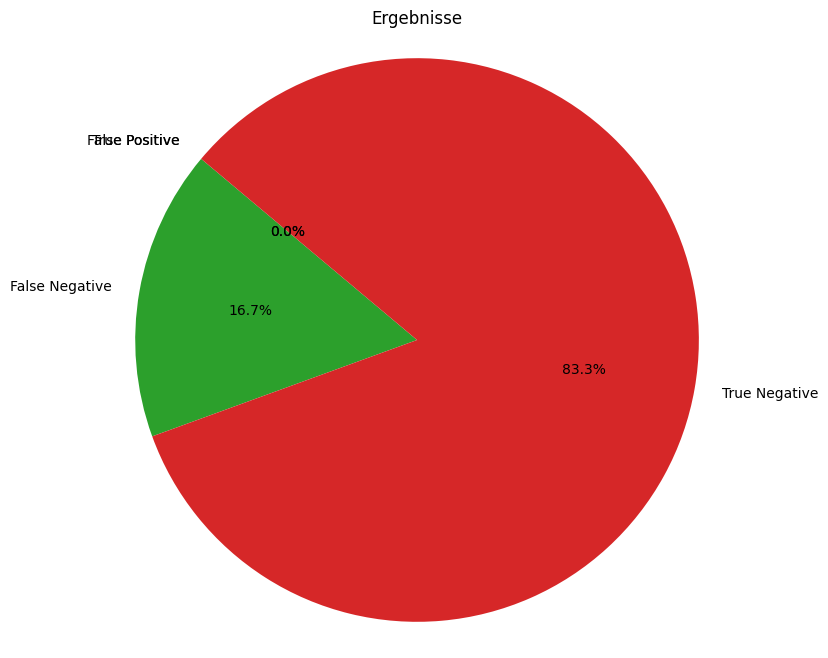

Analyse von MobileNet_Model_4 gegen zufällige Samples:
188/188 [==============================] - 3s 13ms/step
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      5000
           1       0.00      0.00      0.00      1000

    accuracy                           0.83      6000
   macro avg       0.42      0.50      0.45      6000
weighted avg       0.69      0.83      0.76      6000



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


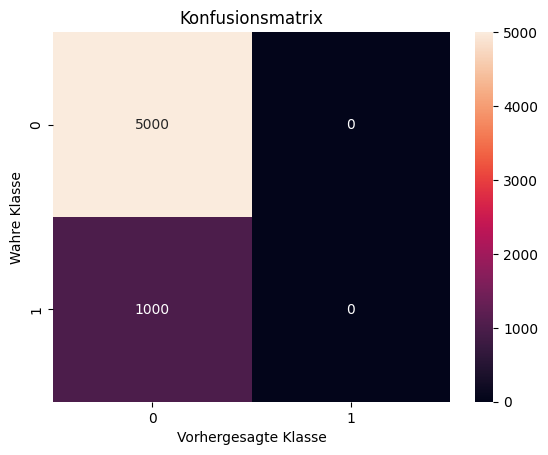

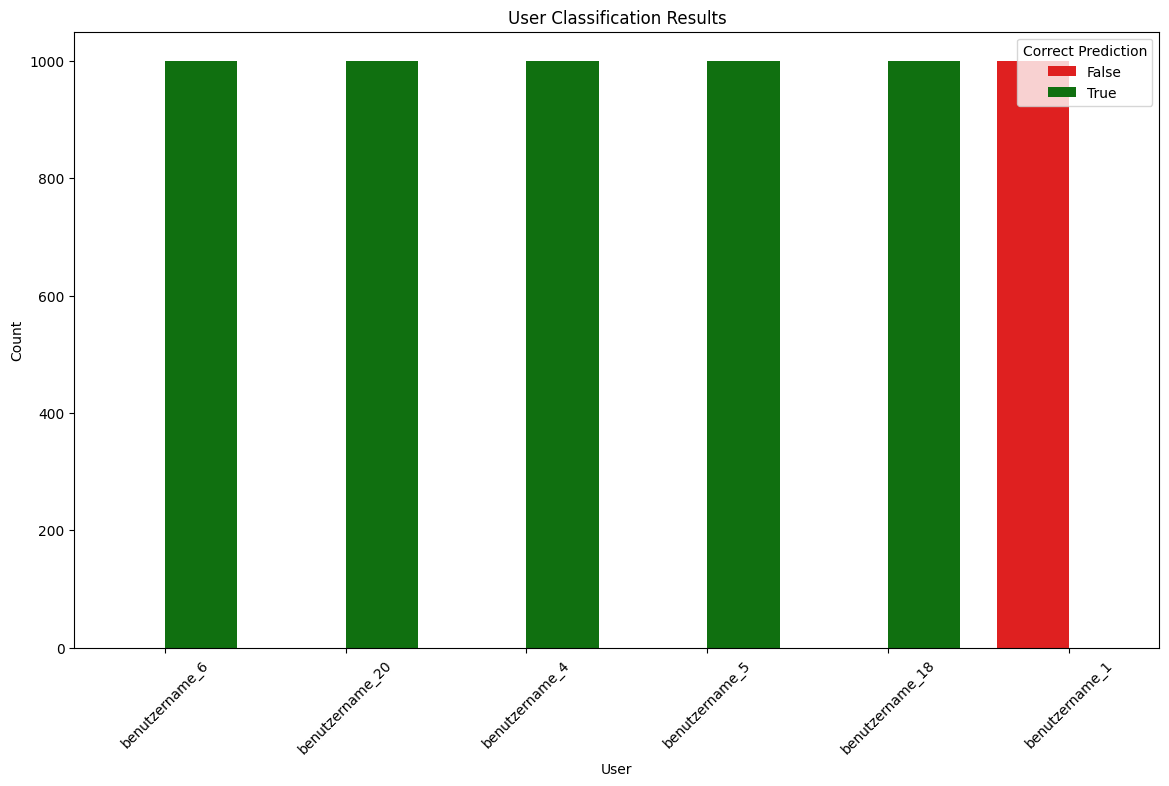

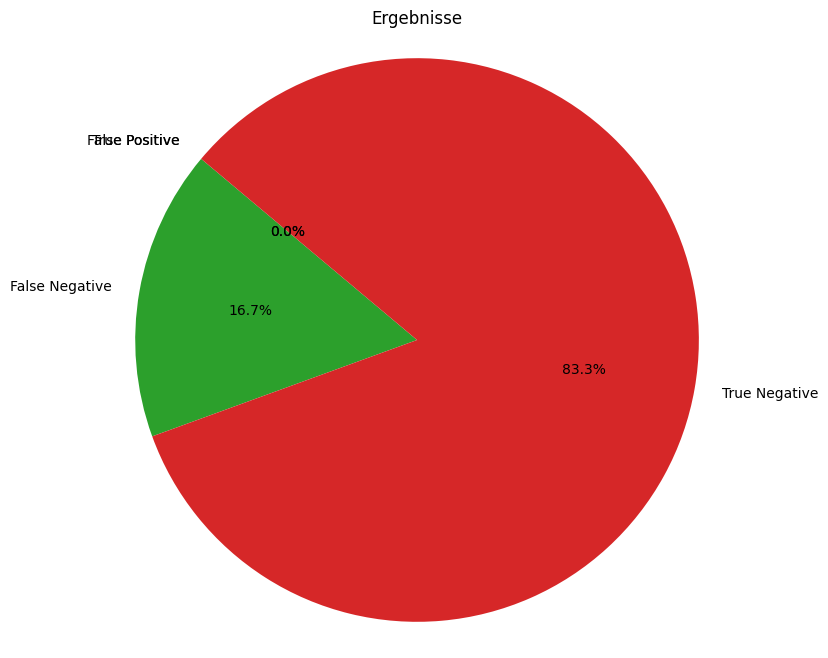

Analyse von MobileNet_Model_3 gegen zufällige Samples:
188/188 [==============================] - 3s 13ms/step
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      5000
           1       0.00      0.00      0.00      1000

    accuracy                           0.83      6000
   macro avg       0.42      0.50      0.45      6000
weighted avg       0.69      0.83      0.76      6000



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


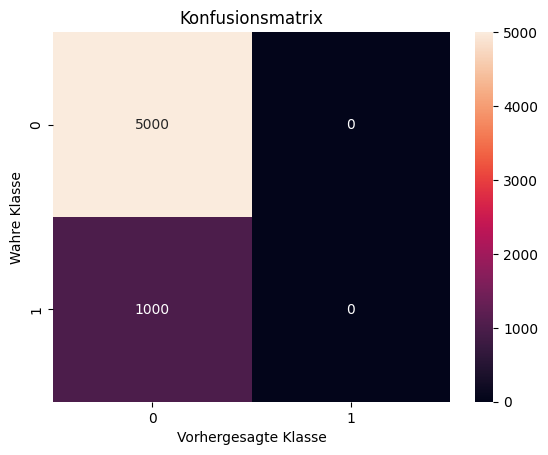

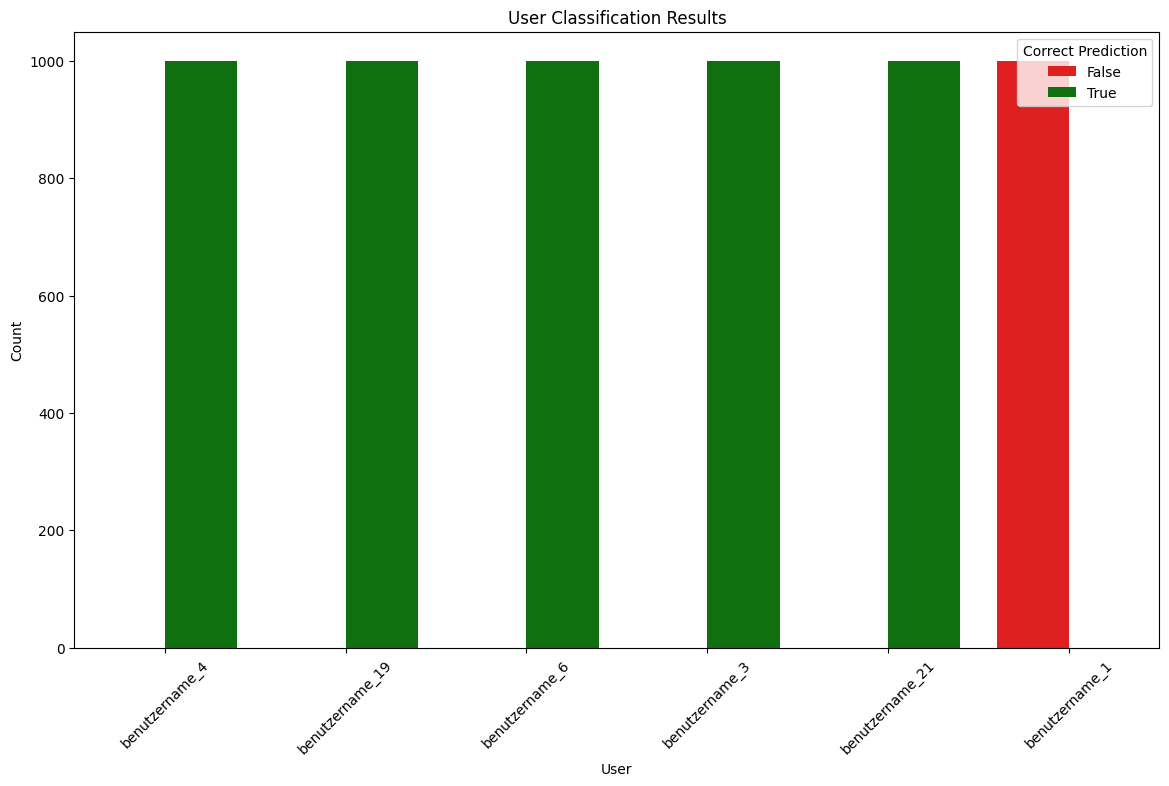

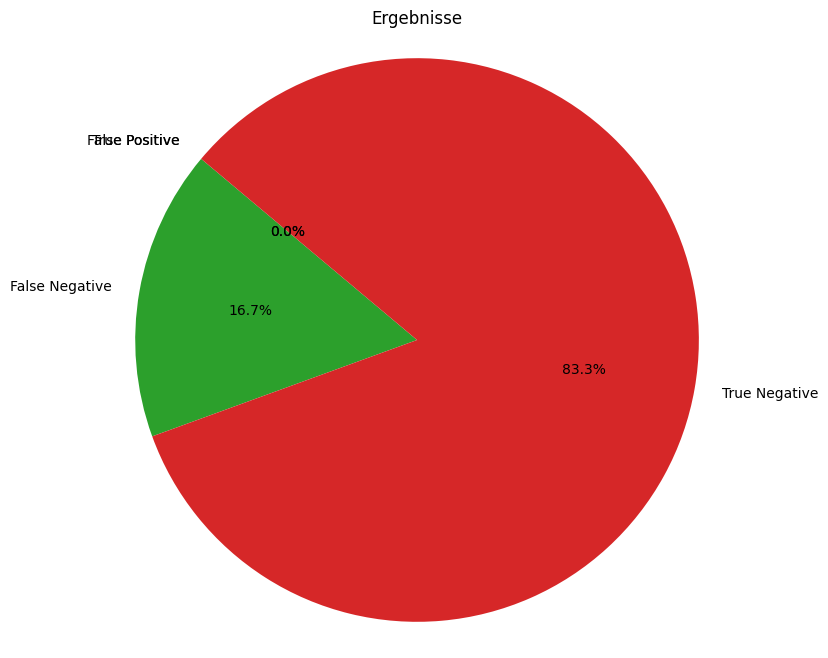

Analyse von MobileNet_Model_2 gegen zufällige Samples:
188/188 [==============================] - 3s 13ms/step
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      5000
           1       0.00      0.00      0.00      1000

    accuracy                           0.83      6000
   macro avg       0.42      0.50      0.45      6000
weighted avg       0.69      0.83      0.76      6000



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


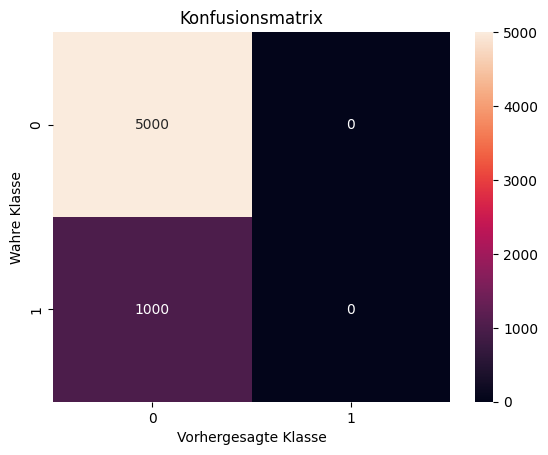

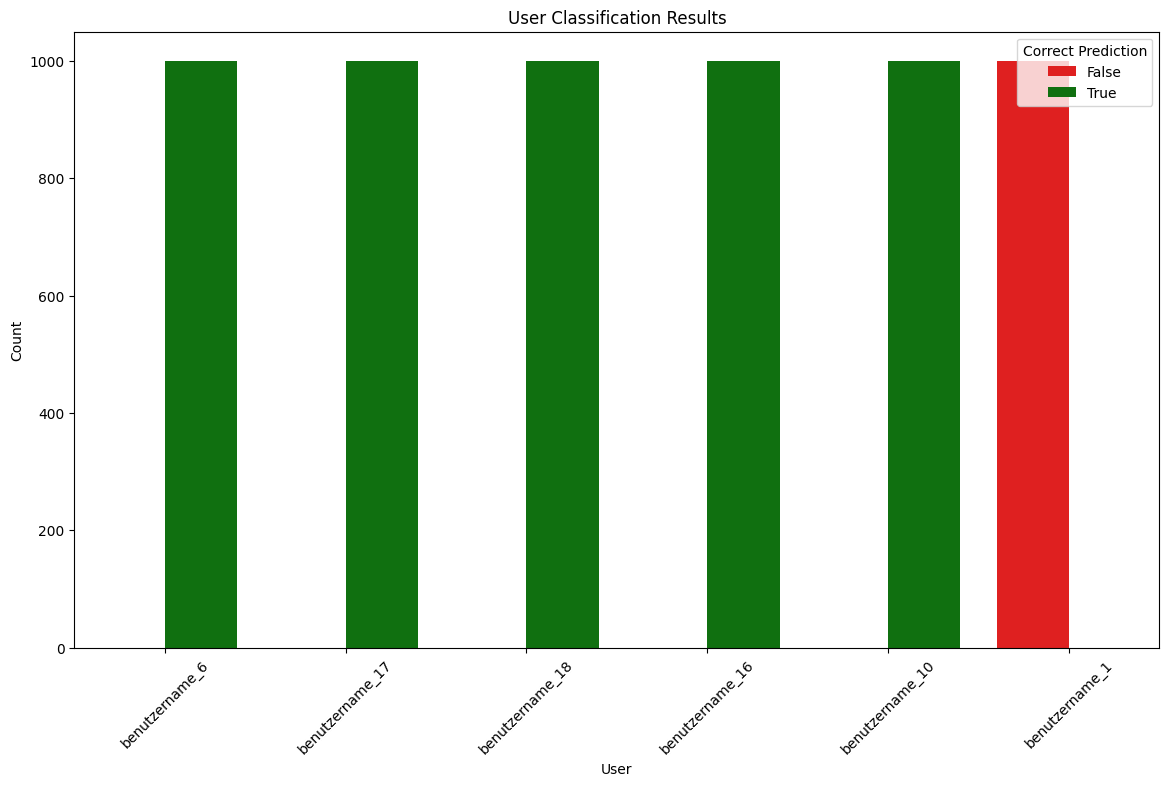

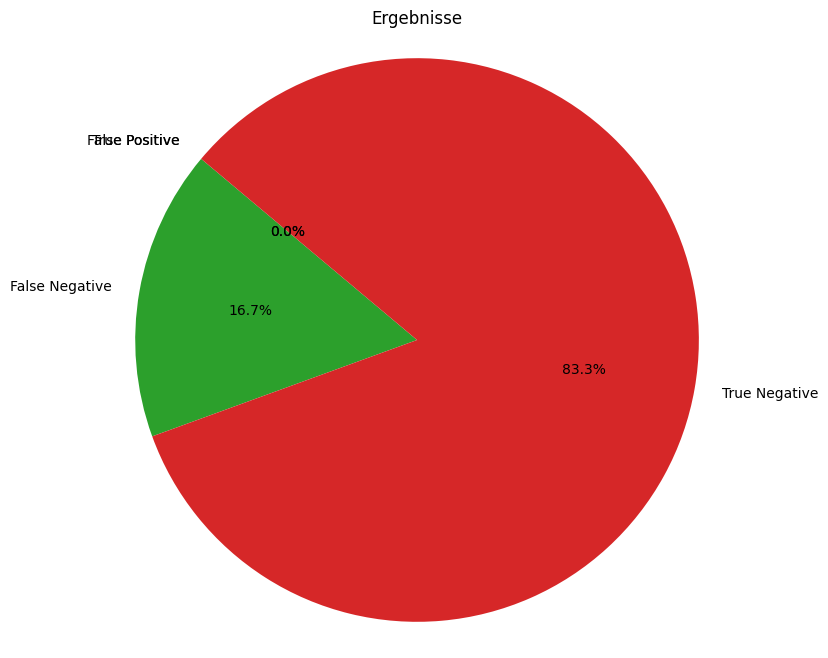

Analyse von MobileNet_Model_1 gegen zufällige Samples:
188/188 [==============================] - 3s 13ms/step
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      5000
           1       0.00      0.00      0.00      1000

    accuracy                           0.83      6000
   macro avg       0.42      0.50      0.45      6000
weighted avg       0.69      0.83      0.76      6000



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


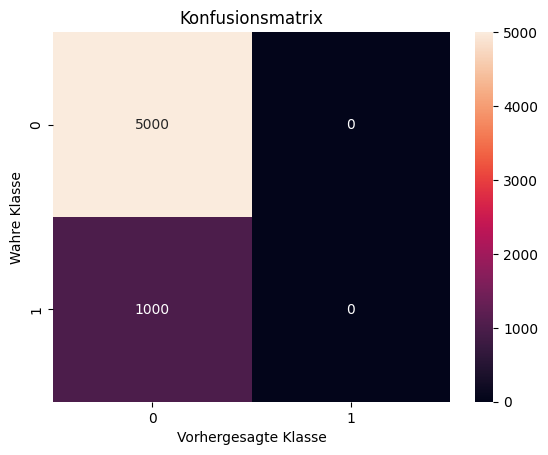

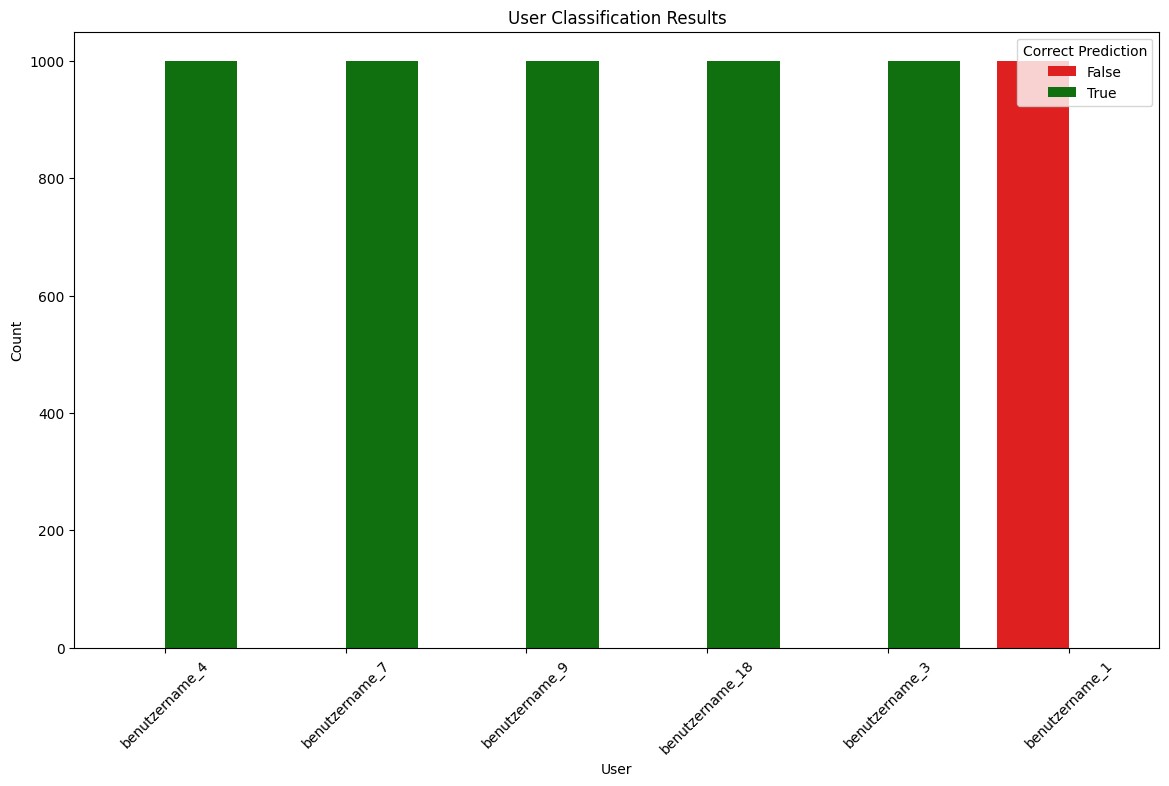

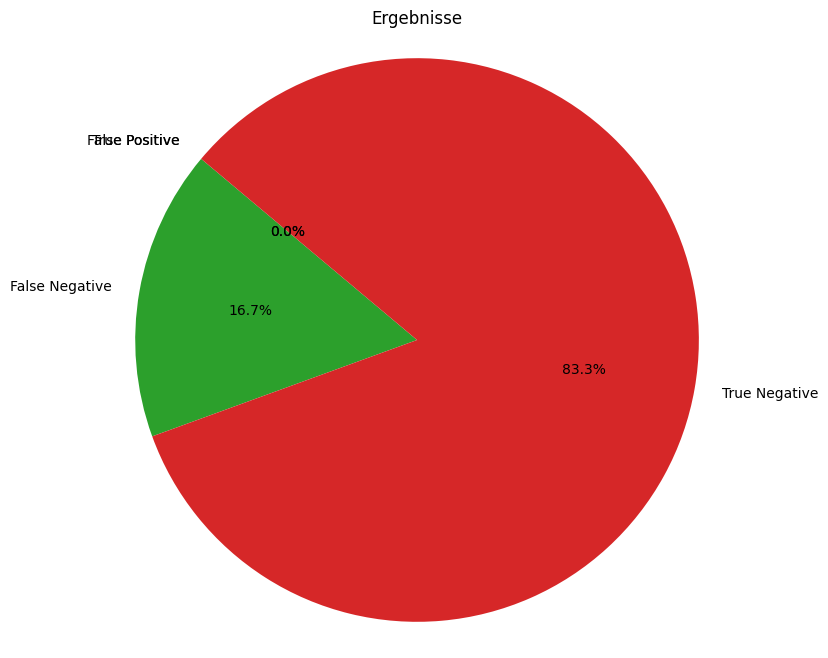

: 

In [ ]:
import os
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import random
from PIL import Image
import io
import base64

# Modelle laden
def load_models(directory='models/version2'):
    loaded_models = {}
    for model_file in os.listdir(directory):
        if model_file.endswith('.h5'):
            model_name = os.path.splitext(model_file)[0]
            model_path = os.path.join(directory, model_file)
            loaded_models[model_name] = load_model(model_path)
            print(f"{model_name} geladen.")
    return loaded_models

# Modelle aus dem Ordner laden
loaded_models = load_models()

# Funktion zur Verarbeitung der Bilder in der richtigen Größe
def process_image_rgb(base64_str, target_size=(224, 224)):  # Ändere die Zielgröße auf (64, 64)
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Konvertiere Bild zu RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalisierung auf Werte zwischen 0 und 1
        return image_array
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

# Funktion zur Auswahl zufälliger Samples von verschiedenen Benutzern
def get_random_samples(user_dfs, example_user_id, num_users=5, num_samples_per_user=1000):
    selected_users = random.sample([user_id for user_id in user_dfs.keys() if user_id != example_user_id], num_users)
    samples = []
    labels = []
    user_labels = []
    
    for user_id in selected_users:
        user_samples = user_dfs[user_id].sample(n=num_samples_per_user, random_state=42)
        for _, row in user_samples.iterrows():
            image = process_image_rgb(row['sampleData'])
            if image is not None:
                samples.append(image)
                labels.append(0)  # Negative Beispiel
                user_labels.append(user_id)
    
    # Füge positive Beispiele hinzu
    user_samples = user_dfs[example_user_id].sample(n=num_samples_per_user, random_state=42)
    for _, row in user_samples.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            samples.append(image)
            labels.append(1)  # Positive Beispiel
            user_labels.append(example_user_id)
    
    return np.array(samples), np.array(labels), user_labels

# Funktion zur Analyse des Modells
def analyze_model(model, user_dfs, example_user_id, num_users=5, num_samples_per_user=1000):
    X_samples, y_samples, user_labels = get_random_samples(user_dfs, example_user_id, num_users, num_samples_per_user)
    y_pred = model.predict(X_samples)
    y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
    
    # Klassifikationsbericht
    print(classification_report(y_samples, y_pred_classes))
    
    # Konfusionsmatrix
    conf_matrix = confusion_matrix(y_samples, y_pred_classes)
    sns.heatmap(conf_matrix, annot=True, fmt='d')
    plt.title('Konfusionsmatrix')
    plt.xlabel('Vorhergesagte Klasse')
    plt.ylabel('Wahre Klasse')
    plt.show()
    
    return y_samples, y_pred_classes, user_labels

# Funktion zur grafischen Darstellung der Benutzerklassifikationen
def plot_user_classifications(y_samples, y_pred_classes, user_labels):
    df = pd.DataFrame({'User': user_labels, 'True Label': y_samples, 'Predicted Label': y_pred_classes})
    df['Correct'] = df['True Label'] == df['Predicted Label']
    
    plt.figure(figsize=(14, 8))
    sns.countplot(data=df, x='User', hue='Correct', palette={True: 'green', False: 'red'}, dodge=True)
    plt.title('User Classification Results')
    plt.xlabel('User')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Correct Prediction')
    plt.show()

# Funktion zur grafischen Darstellung der Ergebnisse in einem Tortendiagramm
def plot_results_pie_chart(y_samples, y_pred_classes):
    cm = confusion_matrix(y_samples, y_pred_classes)
    tn, fp, fn, tp = cm.ravel()
    sizes = [tp, fp, fn, tn]
    labels = ['True Positive', 'False Positive', 'False Negative', 'True Negative']
    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title('Ergebnisse')
    plt.axis('equal')
    plt.show()

# Analyse der geladenen Modelle durchführen
for model_name, model in loaded_models.items():
    print(f"Analyse von {model_name} gegen zufällige Samples:")
    y_samples, y_pred_classes, user_labels = analyze_model(model, user_dfs, example_user_id)
    plot_user_classifications(y_samples, y_pred_classes, user_labels)
    plot_results_pie_chart(y_samples, y_pred_classes)

In [ ]:
import tensorflow as tf
import gc

# Funktion zur Freigabe des Grafikkartenspeichers
def clear_gpu_memory():
    tf.keras.backend.clear_session()
    gc.collect()
    print("Grafikkartenspeicher freigegeben.")

# Speicher freigeben
clear_gpu_memory()

# Speicher freigeben
clear_gpu_memory()